In [1]:
import os, random, numpy as np, tensorflow as tf, pandas as pd

os.environ["PYTHONHASHSEED"] = "0"
random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)

In [2]:
base_dir = "dataset/chest_xray/chest_xray"   # change if needed
trainval_dir = os.path.join(base_dir, "train")  # we'll also include val manually below
val_dir_kaggle = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=5,
    width_shift_range=0.02,
    height_shift_range=0.02,
    zoom_range=0.05,
    brightness_range=(0.9, 1.1),
    horizontal_flip=False
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    trainval_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    trainval_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
# If you don't have classification_models installed, you can use:
# !pip install image-classifiers
from classification_models.tfkeras import Classifiers

# 1. Load the ResNet18 Backbone
ResNet18, preprocess_input = Classifiers.get('resnet18')
base_model = ResNet18(input_shape=(224, 224, 3), weights='imagenet', include_top=False)

# 2. Build the Model (Similar to your MobileNet/SqueezeNet structure)
def build_resnet18():
    inputs = layers.Input(shape=(224, 224, 3))
    
    # Preprocessing is important for ResNet
    x = preprocess_input(inputs)
    x = base_model(x, training=False) # Base model features
    
    # The "Head"
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x) # Optional: helps with overfitting
    output = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs, output, name="ResNet18_Pneumonia")
    return model

# 3. Create and Compile
model = build_resnet18()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auroc"),
        tf.keras.metrics.AUC(name="auprc", curve="PR"),
    ],
)

model.summary()

2026-04-03 08:53:11.661240: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-03 08:53:11.661272: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-04-03 08:53:11.661294: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2026-04-03 08:53:11.661313: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-03 08:53:11.661327: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


44920640/44920640 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "ResNet18_Pneumonia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 7, 7, 512)      │    11,186,889 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,187,402 (42.68 MB)

 Trainable params: 11,179,460 (42.65 MB)

 Non-trainable params: 7,942 (31.02 KB)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 1. EarlyStopping: The "Referee"
# We set patience to 10-12 to give ResNet's skip-connections time to stabilize
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=12, 
    restore_best_weights=True,
    verbose=1
)

# 2. ReduceLROnPlateau: The "Fine-Tuner"
# When the model stops improving, we cut the learning rate to zoom in on better weights
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# 3. ModelCheckpoint: The "Save Game"
# This saves only your best version so you don't lose progress if the power cuts out
checkpoint = ModelCheckpoint(
    'best_resnet18_model.keras',
    monitor='val_auroc', # We prioritize AUROC for medical screening
    mode='max',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, reduce_lr, checkpoint]

In [10]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: 1.9445479962721341, 1: 0.6730645161290323}


In [11]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weights, # Use the same weights as SqueezeNet
    callbacks=callbacks
)

Epoch 1/50


2026-04-03 08:56:50.409595: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.9100 - auprc: 0.9831 - auroc: 0.9578 - loss: 0.2207
Epoch 1: val_auroc improved from None to 0.99931, saving model to best_resnet18_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 71s 419ms/step - accuracy: 0.9444 - auprc: 0.9962 - auroc: 0.9887 - loss: 0.1327 - val_accuracy: 0.9827 - val_auprc: 0.9998 - val_auroc: 0.9993 - val_loss: 0.0442 - learning_rate: 1.0000e-04
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.9813 - auprc: 0.9993 - auroc: 0.9979 - loss: 0.0534
Epoch 2: val_auroc did not improve from 0.99931
131/131 ━━━━━━━━━━━━━━━━━━━━ 48s 358ms/step - accuracy: 0.9784 - auprc: 0.9992 - auroc: 0.9977 - loss: 0.0578 - val_accuracy: 0.8830 - val_auprc: 0.9961 - val_auroc: 0.9863 - val_loss: 0.4274 - learning_rate: 1.0000e-04
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.9892 - auprc: 0.9997 - auroc: 0.9989 - loss: 0.0340
Epoch 3: val_auroc did not improve from 0.99931
131/131 ━━━━━━━━━━━━━━━

In [13]:
from utils import evaluate


evaluate(model, test_gen, threshold=0.5,class_weights=True)


=== model @ threshold 0.500 ===
[[128 106]
 [  3 387]]
              precision    recall  f1-score   support

      NORMAL       0.98      0.55      0.70       234
   PNEUMONIA       0.78      0.99      0.88       390

    accuracy                           0.83       624
   macro avg       0.88      0.77      0.79       624
weighted avg       0.86      0.83      0.81       624

AUROC: 0.9423 | AUPRC: 0.9535
Macro F1: 0.7890 | Weighted F1: 0.8109
Sensitivity: 0.9923 | Specificity: 0.5470 | Precision: 0.7850


{'Model': 'model',
 'Flip': None,
 'Class Weights': True,
 'Threshold': 0.5,
 'AUROC': 0.9423460442691212,
 'AUPRC': 0.953452422773365,
 'Accuracy': 0.8253205128205128,
 'Macro F1': 0.7889635272033386,
 'Weighted F1': 0.8108619432507486,
 'Sensitivity': 0.9923076923076923,
 'Specificity': 0.5470085470085471,
 'Precision': 0.7849898580121704,
 'TN': 128,
 'FP': 106,
 'FN': 3,
 'TP': 387}

In [14]:
#evaluate at best threshold
res_Screen_res = evaluate(model, test_gen,name="resnet_threshold_0.5", threshold=0.5)
res_Screen_res["Params"] = model.count_params()
#add mode params to the result dictionary
res_Screen_res["Mode"] = "Screening"


=== resnet_threshold_0.5 @ threshold 0.500 ===
[[128 106]
 [  3 387]]
              precision    recall  f1-score   support

      NORMAL       0.98      0.55      0.70       234
   PNEUMONIA       0.78      0.99      0.88       390

    accuracy                           0.83       624
   macro avg       0.88      0.77      0.79       624
weighted avg       0.86      0.83      0.81       624

AUROC: 0.9423 | AUPRC: 0.9535
Macro F1: 0.7890 | Weighted F1: 0.8109
Sensitivity: 0.9923 | Specificity: 0.5470 | Precision: 0.7850


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step


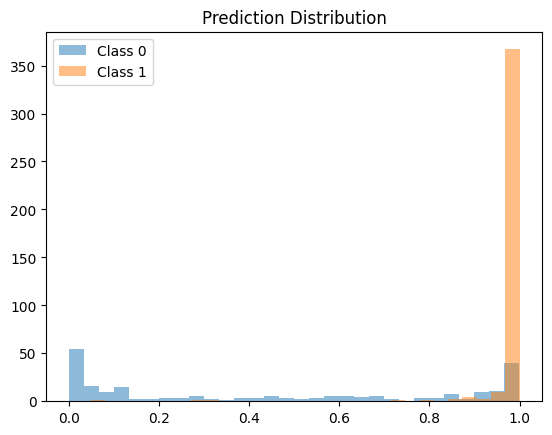

In [15]:
import matplotlib.pyplot as plt

probs = model.predict(test_gen)
y_true = test_gen.classes

plt.hist(probs[y_true==0], bins=30, alpha=0.5, label='Class 0')
plt.hist(probs[y_true==1], bins=30, alpha=0.5, label='Class 1')
plt.legend()
plt.title("Prediction Distribution")
plt.show()

In [16]:
import pandas as pd
from pathlib import Path

out_dir = Path("results")
out_dir.mkdir(exist_ok=True)

pd.DataFrame([res_Screen_res]).to_csv(
    out_dir / "resnet_screen_results.csv",
    index=False
)
